# 040. 영화평 Text 분류 - 단어분리 (Subword Segmentation)

- WPM (Word Piece Model)
    - 하나의 단어를 내부단어 (Subword Unit) 들로 분리하는 단어 분리 모델
    - Google 번역기에서 사용
    

- IMDB (Internet Movie Database, https://www.imdb.com/)  Dataset


- Tensorflow tfds dataset 의 “imdb_reviews/subwords8k” 를 사용하여  “imdb_reviews”  사용시의 결과와 비교  


- 각 25,000 개의 training/testing set 으로 구성된 IMDB 영화관람평  


- “imdb_reviews/subwords8k” - 8,000 개의 subwords 로 사전 encoding 되어 있는 sequence data  


    -  “imdb_reviews” 는 encoding 되어있지 않은 string 형태의 data  
    -  Label : positive, negative binary classification
    
- single Bidirectional LSTM 과 stacked Bidirectional LSTM 두가지 model 비교

## imbd_reviews/subwords8k (pre-encoded data) 이용

In [0]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, Bidirectional
from tensorflow.keras.models import Sequential
import tensorflow_datasets as tfds
import numpy as np

In [2]:
%%time

dataset, info = tfds.load('imdb_reviews/subwords8k', with_info=True,as_supervised=True)

train_dataset, test_dataset = dataset['train'], dataset['test']

CPU times: user 508 ms, sys: 269 ms, total: 777 ms
Wall time: 796 ms


In [3]:
info

tfds.core.DatasetInfo(
    name='imdb_reviews',
    version=1.0.0,
    description='Large Movie Review Dataset.
This is a dataset for binary sentiment classification containing substantially more data than previous benchmark datasets. We provide a set of 25,000 highly polar movie reviews for training, and 25,000 for testing. There is additional unlabeled data for use as well.',
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=tf.int64, num_classes=2),
        'text': Text(shape=(None,), dtype=tf.int64, encoder=<SubwordTextEncoder vocab_size=8185>),
    }),
    total_num_examples=100000,
    splits={
        'test': 25000,
        'train': 25000,
        'unsupervised': 50000,
    },
    supervised_keys=('text', 'label'),
    citation="""@InProceedings{maas-EtAl:2011:ACL-HLT2011,
      author    = {Maas, Andrew L.  and  Daly, Raymond E.  and  Pham, Peter T.  and  Huang, Dan  and  Ng, Andrew Y.  and  Pot

### tfds 는  이미 encoding 되어 있는 tf.data.Dataset 을 return 하므로 data pipeline method 사용하여 sequence padding 을 한다.

In [4]:
encoder = info.features['text'].encoder

print('Vocabulary size: {}'.format(encoder.vocab_size))
print()
print(encoder.subwords[:100])

Vocabulary size: 8185

['the_', ', ', '. ', 'a_', 'and_', 'of_', 'to_', 's_', 'is_', 'br', 'in_', 'I_', 'that_', 'this_', 'it_', ' /><', ' />', 'was_', 'The_', 'as_', 't_', 'with_', 'for_', '.<', 'on_', 'but_', 'movie_', ' (', 'are_', 'his_', 'have_', 'film_', 'not_', 'ing_', 'be_', 'ed_', 'you_', ' "', 'it', 'd_', 'an_', 'he_', 'by_', 'at_', 'one_', 'who_', 'y_', 'from_', 'e_', 'or_', 'all_', 'like_', 'they_', '" ', 'so_', 'just_', 'has_', ') ', 'her_', 'about_', 'out_', 'This_', 'some_', 'ly_', 'movie', 'film', 'very_', 'more_', 'It_', 'would_', 'what_', 'when_', 'which_', 'good_', 'if_', 'up_', 'only_', 'even_', 'their_', 'had_', 'really_', 'my_', 'can_', 'no_', 'were_', 'see_', 'she_', '? ', 'than_', '! ', 'there_', 'get_', 'been_', 'into_', ' - ', 'will_', 'much_', 'story_', 'because_', 'ing']


In [5]:
for input, label in dataset['test']:
    print(f'label : {label}')
    print()
    print(input)
    print()
    print(encoder.decode(input))
    break

label : 1

tf.Tensor(
[ 173   29  185   13  115 1956 8044    3  398 1261 5497  423    2   15
   18 4096 3958  637 2657  552 2893 4926 2314 1673 4587  137   23 4872
 5345    2 7996 7277 8004 8012  137   23  972 5346 5977 1365 8051    2
 7998 3780 1947 1747 4411 3743    3 5064 7961    7   13 2671 4556 3449
 1678  572 8037 7968    8  604 1006 4002 2618 7974 7994 7974 2893 2618
 7974 2475 3912    3 4847 2034 2615   66 7974 3201    2    5   20 1668
 5475 7961    5   20 4474   20  119    6    1 2489 1473 1960  323    3
   12 1167 7968   21 4101   14  366  342   12  284  552 7999 4949 3780
 3779 3369 8018  625 1979    2   78 1259    2   12  109 7968   21  129
   12 4101  236   14 1682  230  392    7 4980 1079 1678  572 8037 7968
    8 1712    9 5795  535  106 4002 2618 7974 7994 7974 2893 2618 7974
 2475 3912 7961    9   55 1296  488  569    6 5852 1125  272 2148 7961
   13   45   70   31    7 1369  267   22    4 2346    6   14  397    5
  110    4  918 7974 1134 7974  557 7716  452    6   15

In [6]:
BUFFER_SIZE = 10000
BATCH_SIZE = 256

train_loader = train_dataset.shuffle(BUFFER_SIZE)
train_loader = train_loader.padded_batch(BATCH_SIZE, train_dataset.output_shapes)

test_loader= test_dataset.padded_batch(BATCH_SIZE, test_dataset.output_shapes)

Instructions for updating:
Use `tf.compat.v1.data.get_output_shapes(dataset)`.


Instructions for updating:
Use `tf.compat.v1.data.get_output_shapes(dataset)`.


## Single Bidirectional LSTM model

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(encoder.vocab_size, 64),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 64)          523840    
_________________________________________________________________
bidirectional (Bidirectional (None, 32)                10368     
_________________________________________________________________
dense (Dense)                (None, 16)                528       
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 17        
Total params: 534,753
Trainable params: 534,753
Non-trainable params: 0
_________________________________________________________________


**validation_steps**  
steps_per_epoch 과 유사한 개념을 test data set 에 적용. 전체 validation set 을 처리할 시간 충분하면 parameter 생략

In [8]:
%%time
history = model.fit(train_loader, epochs=10, validation_data=test_loader, validation_steps=30)

Epoch 1/10
98/98 [==============================] - 22s 227ms/step - loss: 0.6062 - accuracy: 0.6583 - val_loss: 0.4602 - val_accuracy: 0.8107
Epoch 2/10
98/98 [==============================] - 22s 228ms/step - loss: 0.4023 - accuracy: 0.8325 - val_loss: 0.4311 - val_accuracy: 0.8146
Epoch 3/10
98/98 [==============================] - 22s 223ms/step - loss: 0.3241 - accuracy: 0.8755 - val_loss: 0.4275 - val_accuracy: 0.8147
Epoch 4/10
98/98 [==============================] - 22s 224ms/step - loss: 0.2683 - accuracy: 0.9024 - val_loss: 0.4248 - val_accuracy: 0.8290
Epoch 5/10
98/98 [==============================] - 22s 223ms/step - loss: 0.2376 - accuracy: 0.9153 - val_loss: 0.4197 - val_accuracy: 0.8436
Epoch 6/10
98/98 [==============================] - 22s 222ms/step - loss: 0.1925 - accuracy: 0.9347 - val_loss: 0.4232 - val_accuracy: 0.8340
Epoch 7/10
98/98 [==============================] - 22s 225ms/step - loss: 0.1565 - accuracy: 0.9494 - val_loss: 0.4954 - val_accuracy: 0.8384

In [0]:
import matplotlib.pyplot as plt

def plot_graphs(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history['val_' + metric])
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend([metric, 'val_' + metric])
    plt.show()

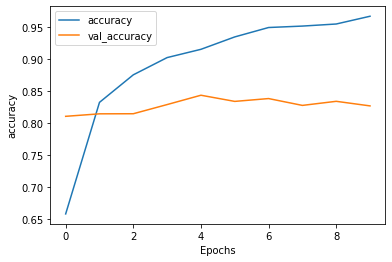

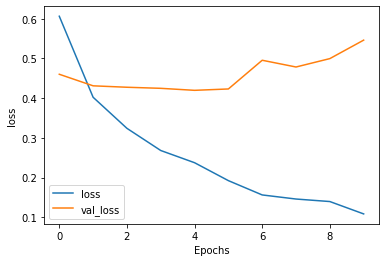

In [10]:
plot_graphs(history, 'accuracy')
plot_graphs(history, 'loss')

### 모델을 이용한 임의의 text 분류 감성 분류

prediction 이 >= 0.5 이면 positive 이고 else 이면 negative.

In [11]:
sample_text = ('The movie was bad. The animation and the graphics '
                    'were terrible. I would not recommend this movie.')

encoded_text = encoder.encode(sample_text)
encoded_text = tf.cast(encoded_text, tf.int64)
encoded_text

<tf.Tensor: shape=(21,), dtype=int64, numpy=
array([  19,   27,   18,  300,    3,   19, 1847,    5,    1, 5172,    8,
         85, 1751,    3,   12,   70,   33,  505,   14,   65, 7975])>

In [12]:
predictions = model.predict(tf.expand_dims(encoded_text, 0))
predictions

array([[0.02305174]], dtype=float32)

## stacked Bidirectional LSTM 으로 single LSTM 과 결과 비교

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(encoder.vocab_size, 64),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16,  return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, None, 64)          523840    
_________________________________________________________________
bidirectional_1 (Bidirection (None, None, 32)          10368     
_________________________________________________________________
bidirectional_2 (Bidirection (None, 32)                6272      
_________________________________________________________________
dense_2 (Dense)              (None, 16)                528       
_________________________________________________________________
dropout (Dropout)            (None, 16)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 17        
Total params: 541,025
Trainable params: 541,025
Non-trainable params: 0
________________________________________________

In [14]:
%%time
history = model.fit(train_loader, epochs=10, validation_data=test_loader, validation_steps=30)

Epoch 1/10
98/98 [==============================] - 36s 366ms/step - loss: 0.6323 - accuracy: 0.6426 - val_loss: 0.5319 - val_accuracy: 0.7533
Epoch 2/10
98/98 [==============================] - 36s 370ms/step - loss: 0.4509 - accuracy: 0.8250 - val_loss: 0.4270 - val_accuracy: 0.8163
Epoch 3/10
98/98 [==============================] - 36s 367ms/step - loss: 0.3322 - accuracy: 0.8829 - val_loss: 0.4054 - val_accuracy: 0.8236
Epoch 4/10
98/98 [==============================] - 36s 369ms/step - loss: 0.2516 - accuracy: 0.9188 - val_loss: 0.4130 - val_accuracy: 0.8475
Epoch 5/10
98/98 [==============================] - 36s 369ms/step - loss: 0.2154 - accuracy: 0.9334 - val_loss: 0.4728 - val_accuracy: 0.8444
Epoch 6/10
98/98 [==============================] - 36s 368ms/step - loss: 0.1693 - accuracy: 0.9512 - val_loss: 0.5216 - val_accuracy: 0.8327
Epoch 7/10
98/98 [==============================] - 36s 372ms/step - loss: 0.1311 - accuracy: 0.9641 - val_loss: 0.5874 - val_accuracy: 0.8303

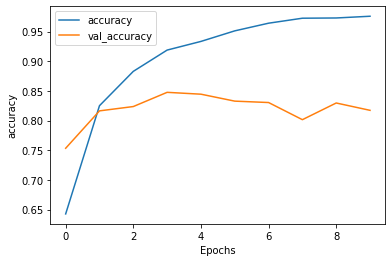

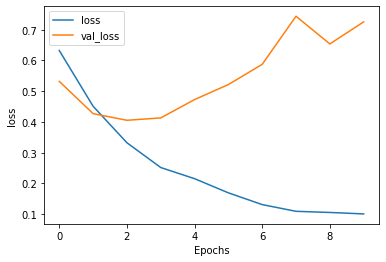

In [15]:
plot_graphs(history, 'accuracy')
plot_graphs(history, 'loss')

In [19]:
sample_text = ('The movie was good. The animation and the graphics '
                    'were amazing. I would recommend this movie.')

encoded_text = encoder.encode(sample_text)
encoded_text = tf.cast(encoded_text, tf.int64)
encoded_text

<tf.Tensor: shape=(20,), dtype=int64, numpy=
array([  19,   27,   18,  248,    3,   19, 1847,    5,    1, 5172,    8,
         85, 2266,    3,   12,   70,  505,   14,   65, 7975])>

In [20]:
predictions = model.predict(tf.expand_dims(encoded_text, 0))
predictions

array([[0.84363645]], dtype=float32)